# Joint-state tracking error

This notebook compares the post-physics G1 joint positions and velocities against the reference frame used for that control step in `lunges2_trace.csv` and `lunges2gg_trace.csv`.

The signed error convention is

$$e_q(t) = q_{\mathrm{robot}}(t) - q_{\mathrm{ref}}(t), \qquad e_v(t) = v_{\mathrm{robot}}(t) - v_{\mathrm{ref}}(t).$$

Position error is measured in radians and velocity error in radians per second. Because those units cannot be combined directly, the state RMSE uses configurable position and velocity scales to create a dimensionless error for $x=[q, v]$. The notebook also retains the signed position-error heatmaps and per-joint diagnostics.

In [4]:
from __future__ import annotations

import csv
import json
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm


def find_repo_root(start: Path | None = None) -> Path:
  """Find the mjlab checkout from either the repo root or notebooks/."""
  start = (start or Path.cwd()).resolve()
  for candidate in (start, *start.parents):
    if (candidate / "pyproject.toml").is_file() and (candidate / "logs").is_dir():
      return candidate
  raise FileNotFoundError(
    "Could not find the repository root. Start Jupyter inside the mjlab checkout."
  )


ROOT = find_repo_root()
TRACE_FILES = {
  "lunges2": ROOT / "logs/lunges2_trace.csv",
  "lunges2gg": ROOT / "logs/lunges2gg_trace.csv",
}

# Characteristic tolerances used to combine position and velocity errors.
# A normalized error of 1.0 means one scale unit away from the reference.
POSITION_ERROR_SCALE_RAD = 0.1
VELOCITY_ERROR_SCALE_RAD_S = 1.0

# Set this to False if you only want inline notebook figures.
SAVE_FIGURES = True
OUTPUT_DIR = ROOT / "logs/joint_error_plots"
if SAVE_FIGURES:
  OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
print(f"Repository: {ROOT}")
print(f"Figure output: {OUTPUT_DIR if SAVE_FIGURES else 'disabled'}")

Repository: /home/nathan/Desktop/mjlab-trained
Figure output: /home/nathan/Desktop/mjlab-trained/logs/joint_error_plots


In [5]:
@dataclass(frozen=True)
class JointTrace:
  label: str
  csv_path: Path
  time_s: np.ndarray
  motion_frame: np.ndarray
  joint_names: tuple[str, ...]
  q_ref: np.ndarray
  q_robot: np.ndarray
  v_ref: np.ndarray
  v_robot: np.ndarray

  @property
  def position_error(self) -> np.ndarray:
    return self.q_robot - self.q_ref

  @property
  def velocity_error(self) -> np.ndarray:
    return self.v_robot - self.v_ref

  @property
  def frame_position_rmse(self) -> np.ndarray:
    return np.sqrt(np.mean(self.position_error**2, axis=1))

  @property
  def frame_velocity_rmse(self) -> np.ndarray:
    return np.sqrt(np.mean(self.velocity_error**2, axis=1))

  def frame_state_rmse(
    self, position_scale_rad: float, velocity_scale_rad_s: float
  ) -> np.ndarray:
    if position_scale_rad <= 0.0 or velocity_scale_rad_s <= 0.0:
      raise ValueError("State-error scales must be positive.")
    normalized_error = np.concatenate(
      [
        self.position_error / position_scale_rad,
        self.velocity_error / velocity_scale_rad_s,
      ],
      axis=1,
    )
    return np.sqrt(np.mean(normalized_error**2, axis=1))

  @property
  def frame_mean_signed_position_error(self) -> np.ndarray:
    return np.mean(self.position_error, axis=1)

  @property
  def joint_position_rmse(self) -> np.ndarray:
    return np.sqrt(np.mean(self.position_error**2, axis=0))

  @property
  def joint_velocity_rmse(self) -> np.ndarray:
    return np.sqrt(np.mean(self.velocity_error**2, axis=0))

  @property
  def joint_mean_signed_position_error(self) -> np.ndarray:
    return np.mean(self.position_error, axis=0)


def load_joint_trace(label: str, csv_path: Path) -> JointTrace:
  metadata_path = Path(f"{csv_path}.metadata.json")
  if not csv_path.is_file():
    raise FileNotFoundError(f"Missing trace: {csv_path}")
  if not metadata_path.is_file():
    raise FileNotFoundError(f"Missing metadata: {metadata_path}")

  metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
  joint_names = tuple(metadata["joint_names"])

  with csv_path.open(newline="", encoding="utf-8") as file:
    rows = list(csv.DictReader(file))
  if not rows:
    raise ValueError(f"Trace has no data rows: {csv_path}")

  required = {
    "sim_time_s",
    "motion_frame",
    "reference_joint_pos",
    "actual_joint_pos",
    "reference_joint_vel",
    "actual_joint_vel",
  }
  missing = required.difference(rows[0])
  if missing:
    raise ValueError(
      f"{csv_path.name} is missing columns: {sorted(missing)}. "
      "Regenerate the trace with the updated debug_tracking_step.py."
    )

  time_s = np.asarray([float(row["sim_time_s"]) for row in rows])
  motion_frame = np.asarray([int(row["motion_frame"]) for row in rows])
  q_ref = np.asarray(
    [json.loads(row["reference_joint_pos"]) for row in rows], dtype=float
  )
  q_robot = np.asarray(
    [json.loads(row["actual_joint_pos"]) for row in rows], dtype=float
  )
  v_ref = np.asarray(
    [json.loads(row["reference_joint_vel"]) for row in rows], dtype=float
  )
  v_robot = np.asarray(
    [json.loads(row["actual_joint_vel"]) for row in rows], dtype=float
  )

  expected_shape = (len(rows), len(joint_names))
  arrays = {
    "q_ref": q_ref,
    "q_robot": q_robot,
    "v_ref": v_ref,
    "v_robot": v_robot,
  }
  invalid_shapes = {
    name: value.shape for name, value in arrays.items() if value.shape != expected_shape
  }
  if invalid_shapes:
    raise ValueError(
      f"Unexpected joint array shape in {csv_path.name}: "
      f"{invalid_shapes}, expected={expected_shape}"
    )
  if not all(np.isfinite(value).all() for value in arrays.values()):
    raise ValueError(f"Non-finite joint value found in {csv_path.name}")

  return JointTrace(
    label=label,
    csv_path=csv_path,
    time_s=time_s,
    motion_frame=motion_frame,
    joint_names=joint_names,
    q_ref=q_ref,
    q_robot=q_robot,
    v_ref=v_ref,
    v_robot=v_robot,
  )


def save_figure(fig: plt.Figure, filename: str) -> None:
  if not SAVE_FIGURES:
    return
  output_path = OUTPUT_DIR / filename
  fig.savefig(output_path, dpi=180, bbox_inches="tight")
  print(f"Saved {output_path.relative_to(ROOT)}")


traces = {label: load_joint_trace(label, path) for label, path in TRACE_FILES.items()}
joint_orders = {trace.joint_names for trace in traces.values()}
if len(joint_orders) != 1:
  raise ValueError("The traces use different joint names or joint ordering.")
joint_names = next(iter(joint_orders))

palette = plt.get_cmap("tab10")
colors = {label: palette(index) for index, label in enumerate(traces)}

header = (
  f"{'trace':<12} {'samples':>8} {'duration [s]':>14} "
  f"{'mean q RMSE':>14} {'mean v RMSE':>14} {'mean x RMSE':>14}"
)
print(header)
for trace in traces.values():
  state_rmse = trace.frame_state_rmse(
    POSITION_ERROR_SCALE_RAD, VELOCITY_ERROR_SCALE_RAD_S
  )
  print(
    f"{trace.label:<12} {len(trace.time_s):>8} "
    f"{trace.time_s[-1] - trace.time_s[0]:>14.3f} "
    f"{trace.frame_position_rmse.mean():>14.5f} "
    f"{trace.frame_velocity_rmse.mean():>14.5f} "
    f"{state_rmse.mean():>14.5f}"
  )

trace         samples   duration [s]    mean q RMSE    mean v RMSE    mean x RMSE
lunges2           279          5.560        0.07317        0.29328        0.56882
lunges2gg         279          5.560        0.08277        0.35341        0.65358


## Per-frame summary

The first two panels show position and velocity RMSE across all 29 joints. The third shows the normalized RMSE of the 58-element state $x=[q,v]$:

$$\operatorname{RMSE}_x(t)=\sqrt{\frac{1}{2N}\sum_{j=1}^{N}\left[\left(\frac{e_{q,j}}{s_q}\right)^2+\left(\frac{e_{v,j}}{s_v}\right)^2\right]}.$$

The scales $s_q$ and $s_v$ are configured near the top of the notebook. The final panel retains the mean signed position error; positive and negative joint errors can cancel in that panel.

Saved logs/joint_error_plots/joint_state_frame_summary.png


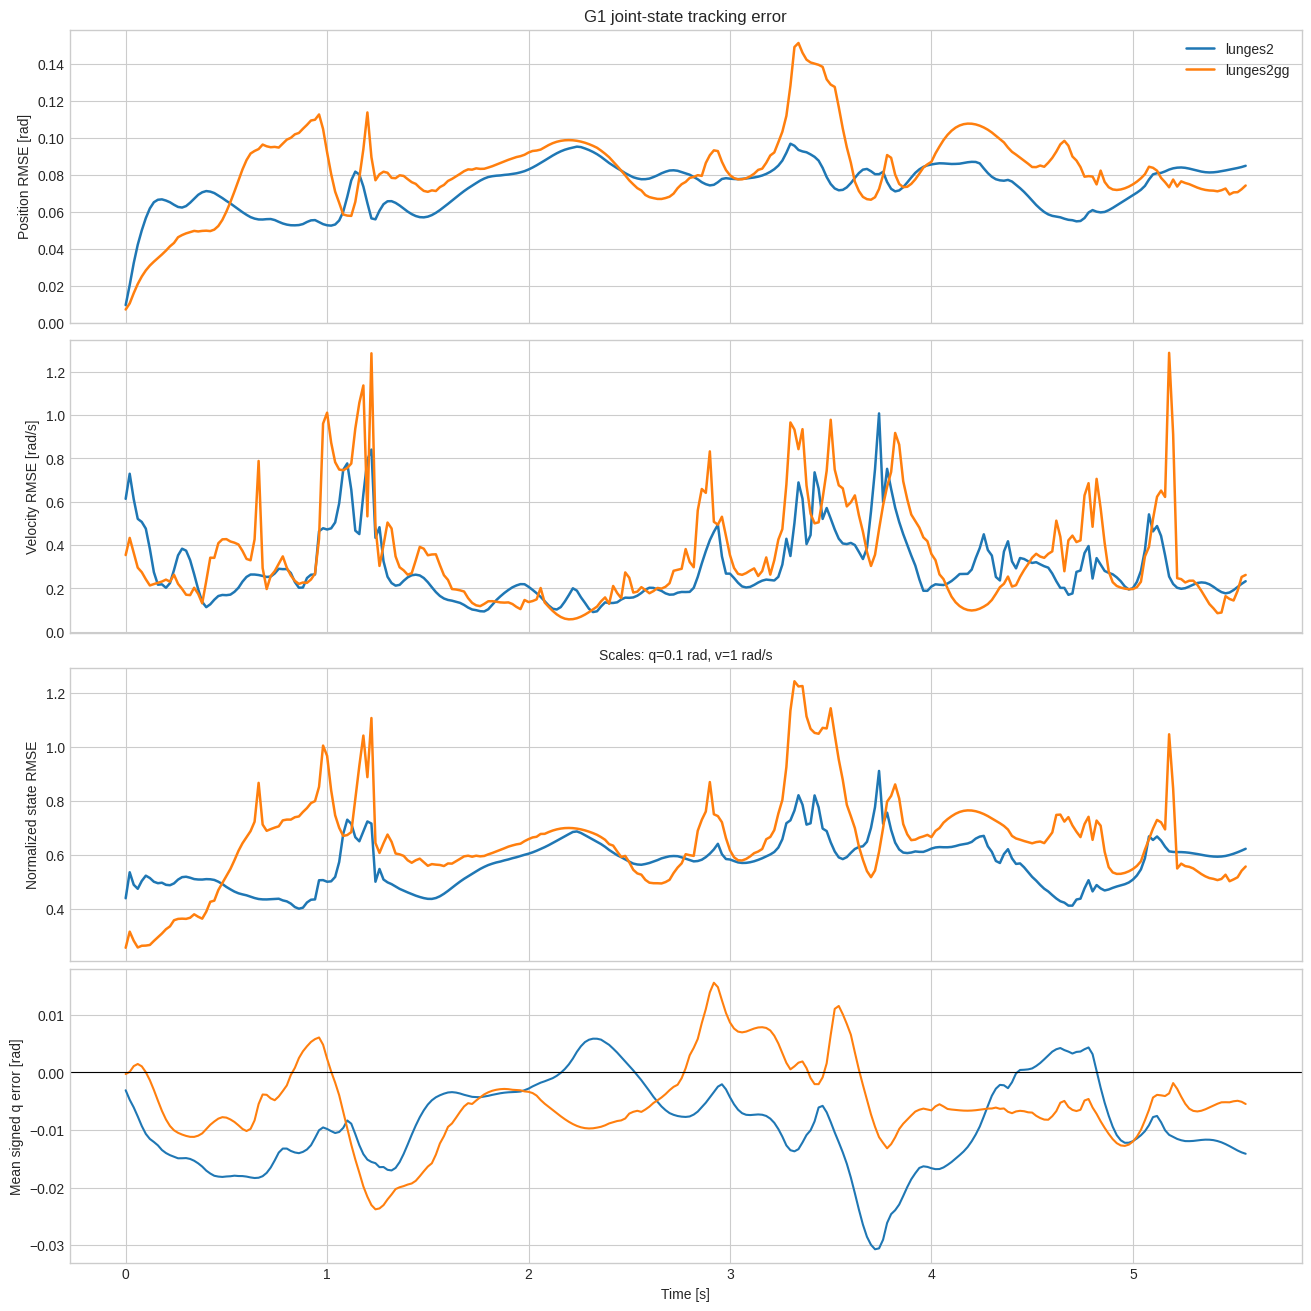

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(13, 13), sharex=True, constrained_layout=True)

for label, trace in traces.items():
  axes[0].plot(
    trace.time_s,
    trace.frame_position_rmse,
    label=label,
    color=colors[label],
    linewidth=1.8,
  )
  axes[1].plot(
    trace.time_s,
    trace.frame_velocity_rmse,
    label=label,
    color=colors[label],
    linewidth=1.8,
  )
  axes[2].plot(
    trace.time_s,
    trace.frame_state_rmse(POSITION_ERROR_SCALE_RAD, VELOCITY_ERROR_SCALE_RAD_S),
    label=label,
    color=colors[label],
    linewidth=1.8,
  )
  axes[3].plot(
    trace.time_s,
    trace.frame_mean_signed_position_error,
    label=label,
    color=colors[label],
    linewidth=1.5,
  )

axes[0].set_title("G1 joint-state tracking error")
axes[0].set_ylabel("Position RMSE [rad]")
axes[0].legend()
axes[1].set_ylabel("Velocity RMSE [rad/s]")
axes[2].set_ylabel("Normalized state RMSE")
axes[2].set_title(
  f"Scales: q={POSITION_ERROR_SCALE_RAD:g} rad, v={VELOCITY_ERROR_SCALE_RAD_S:g} rad/s",
  fontsize=10,
)
axes[3].axhline(0.0, color="black", linewidth=0.8)
axes[3].set_ylabel("Mean signed q error [rad]")
axes[3].set_xlabel("Time [s]")

save_figure(fig, "joint_state_frame_summary.png")
plt.show()

## Signed-error heatmaps

Both plots use the same symmetric color scale. Red is positive $q_{\mathrm{robot}}-q_{\mathrm{ref}}$; blue is negative.

Saved logs/joint_error_plots/joint_error_signed_heatmaps.png


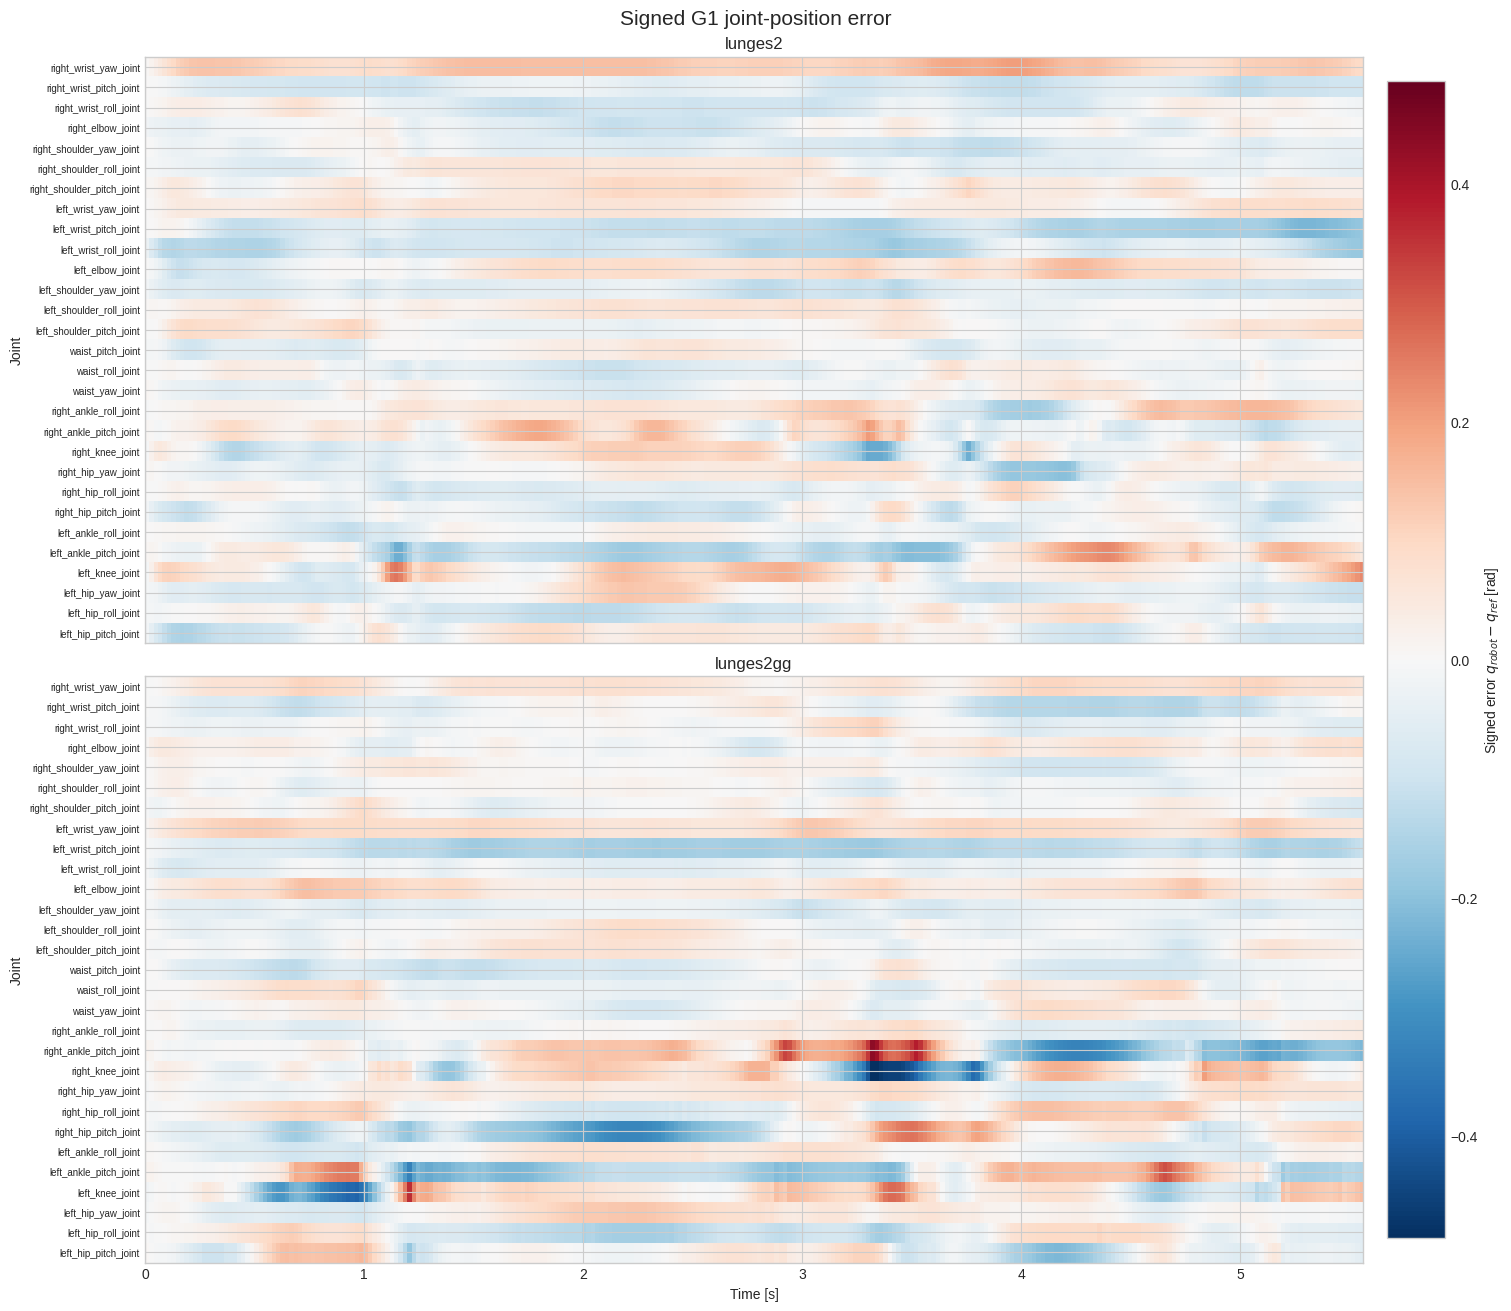

In [7]:
color_limit = max(
  float(np.abs(trace.position_error).max()) for trace in traces.values()
)
color_limit = max(color_limit, np.finfo(float).eps)
norm = TwoSlopeNorm(vmin=-color_limit, vcenter=0.0, vmax=color_limit)

fig, axes = plt.subplots(
  len(traces),
  1,
  figsize=(15, 13),
  sharex=True,
  constrained_layout=True,
  squeeze=False,
)
axes = axes[:, 0]

for axis, (label, trace) in zip(axes, traces.items(), strict=True):
  image = axis.imshow(
    trace.position_error.T,
    aspect="auto",
    origin="lower",
    extent=(trace.time_s[0], trace.time_s[-1], -0.5, len(joint_names) - 0.5),
    cmap="RdBu_r",
    norm=norm,
    interpolation="nearest",
  )
  axis.set_title(label)
  axis.set_yticks(np.arange(len(joint_names)), labels=joint_names, fontsize=7)
  axis.set_ylabel("Joint")

axes[-1].set_xlabel("Time [s]")
colorbar = fig.colorbar(image, ax=axes, pad=0.02, shrink=0.96)
colorbar.set_label(r"Signed error $q_{robot}-q_{ref}$ [rad]")
fig.suptitle("Signed G1 joint-position error", fontsize=15)

save_figure(fig, "joint_error_signed_heatmaps.png")
plt.show()

## Individual signed joint-error curves

By default this plots all 29 joints and overlays the two traces. Replace `JOINTS_TO_PLOT` with a smaller tuple of names if you want to inspect selected joints only.

Saved logs/joint_error_plots/joint_error_all_joint_curves.png


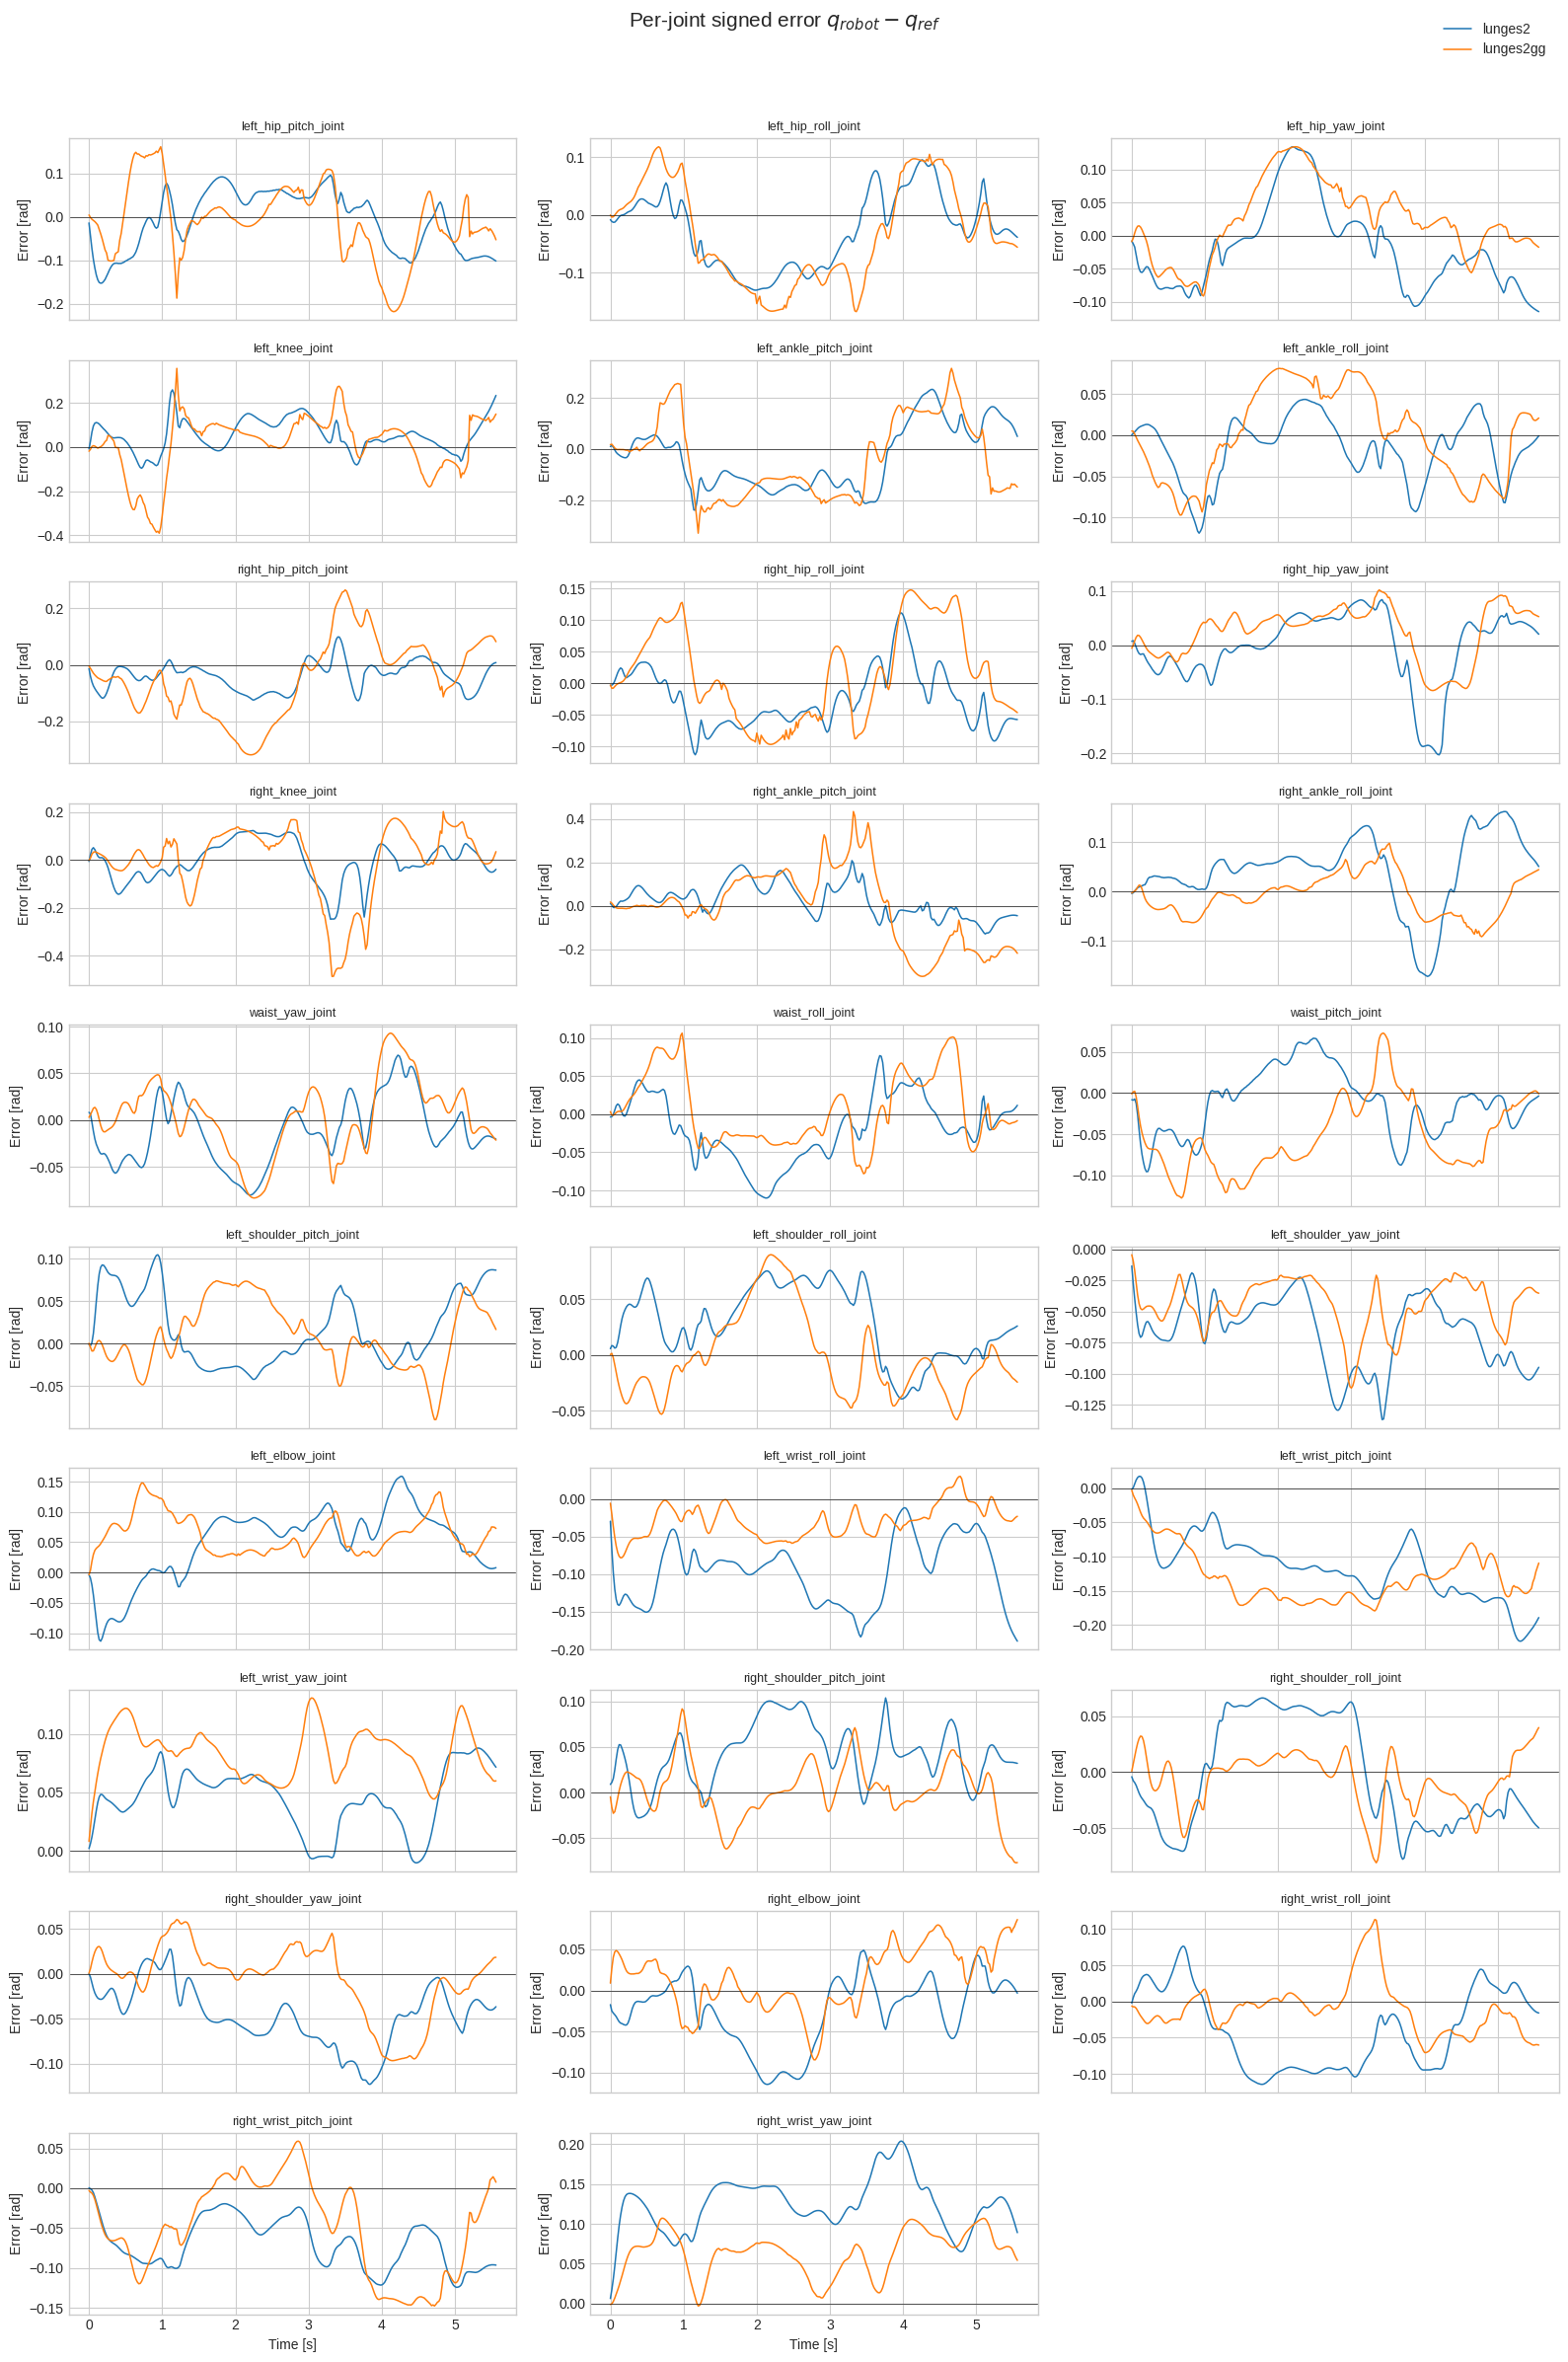

In [8]:
JOINTS_TO_PLOT = joint_names
# Example subset:
# JOINTS_TO_PLOT = (
#     "left_hip_pitch_joint",
#     "left_knee_joint",
#     "right_hip_pitch_joint",
#     "right_knee_joint",
# )

unknown_joints = set(JOINTS_TO_PLOT).difference(joint_names)
if unknown_joints:
  raise ValueError(f"Unknown joint names: {sorted(unknown_joints)}")

ncols = min(3, len(JOINTS_TO_PLOT))
nrows = int(np.ceil(len(JOINTS_TO_PLOT) / ncols))
fig, axes = plt.subplots(
  nrows,
  ncols,
  figsize=(16, max(3.2, 2.4 * nrows)),
  sharex=True,
  squeeze=False,
)uv run python scripts/debug_tracking_step.py \
  Mjlab-Tracking-Flat-Unitree-G1 \
  --checkpoint-file logs/rsl_rl/g1_tracking/2026-08-12_18-43-33_lunges2gg/model_20000.pt \
  --motion-file motion/lunges2gg.npz \
  --output-file logs/lunges2gg_trace.csv \
  --disable-terminations True
flat_axes = axes.ravel()

for axis, joint_name in zip(flat_axes, JOINTS_TO_PLOT, strict=False):
  joint_index = joint_names.index(joint_name)
  for label, trace in traces.items():
    axis.plot(
      trace.time_s,
      trace.position_error[:, joint_index],
      color=colors[label],
      label=label,
      linewidth=1.1,
    )
  axis.axhline(0.0, color="black", linewidth=0.6, alpha=0.7)
  axis.set_title(joint_name, fontsize=9)
  axis.set_ylabel("Error [rad]")

for axis in flat_axes[len(JOINTS_TO_PLOT) :]:
  axis.set_visible(False)
for axis in axes[-1, :]:
  if axis.get_visible():
    axis.set_xlabel("Time [s]")

handles, labels = flat_axes[0].get_legend_handles_labels()
fig.legend(
  handles, labels, loc="upper right", bbox_to_anchor=(0.99, 0.995), frameon=False
)
fig.suptitle(r"Per-joint signed error $q_{robot}-q_{ref}$", y=0.995, fontsize=15)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.97))

save_figure(fig, "joint_error_all_joint_curves.png")
plt.show()

## Per-joint bias and RMSE

Mean signed error identifies a consistent directional bias. RMSE measures error magnitude without cancellation.

Saved logs/joint_error_plots/joint_error_per_joint_summary.png


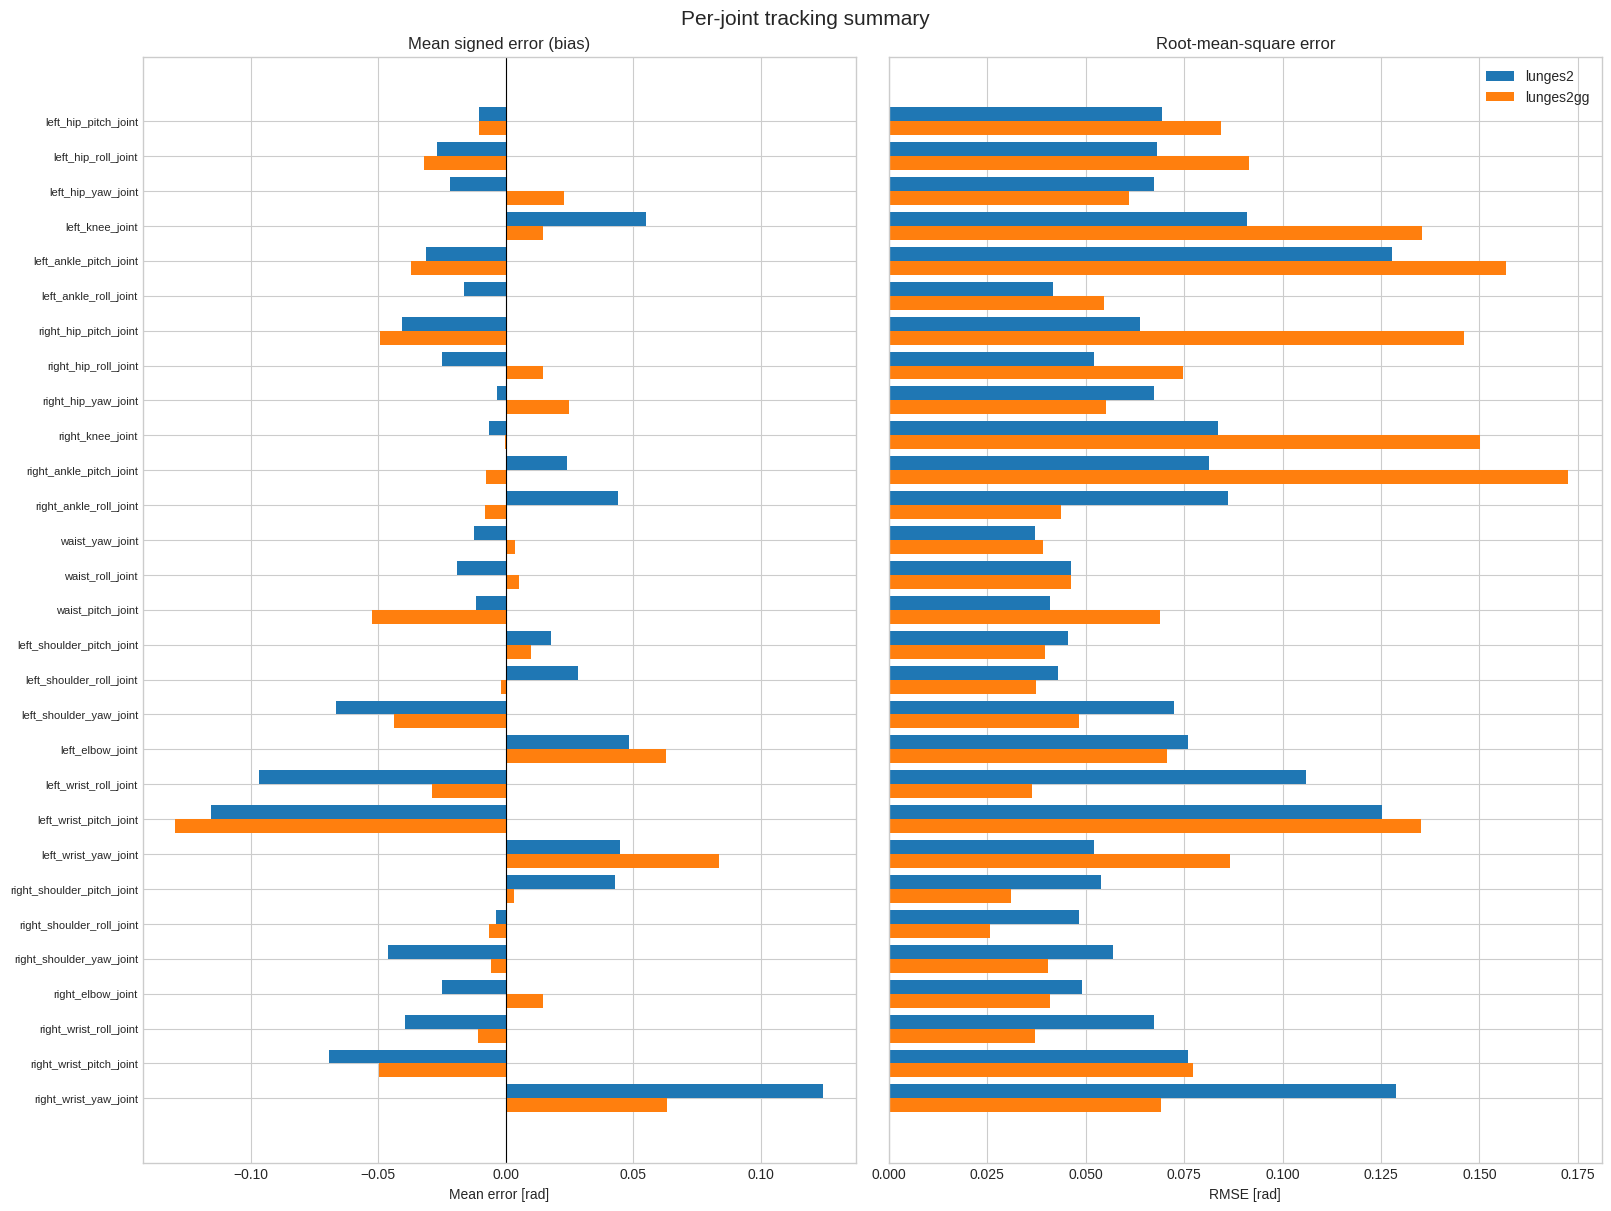

In [9]:
y = np.arange(len(joint_names), dtype=float)
bar_height = 0.8 / len(traces)
fig, axes = plt.subplots(1, 2, figsize=(16, 12), sharey=True, constrained_layout=True)

for trace_index, (label, trace) in enumerate(traces.items()):
  offset = (trace_index - (len(traces) - 1) / 2) * bar_height
  axes[0].barh(
    y + offset,
    trace.joint_mean_signed_position_error,
    height=bar_height,
    color=colors[label],
    label=label,
  )
  axes[1].barh(
    y + offset,
    trace.joint_position_rmse,
    height=bar_height,
    color=colors[label],
    label=label,
  )

axes[0].axvline(0.0, color="black", linewidth=0.8)
axes[0].set_title("Mean signed error (bias)")
axes[0].set_xlabel("Mean error [rad]")
axes[1].set_title("Root-mean-square error")
axes[1].set_xlabel("RMSE [rad]")
axes[1].legend()
axes[0].set_yticks(y, labels=joint_names, fontsize=8)
axes[0].invert_yaxis()
fig.suptitle("Per-joint tracking summary", fontsize=15)

save_figure(fig, "joint_error_per_joint_summary.png")
plt.show()

## Output

When `SAVE_FIGURES = True`, the generated PNG files are written to `logs/joint_error_plots/`. The source traces compare each snapshotted reference position and velocity with the robot state after the corresponding physics step, as recorded by `scripts/debug_tracking_step.py`.